# Notebook 02 — Preprocessing, Proxy Label, dan Pembagian Dataset

**Deskripsi:**
Notebook ini melanjutkan hasil dari Notebook 01 dan mencakup tahapan:
1. Instalasi library dan import dependensi
2. Pembacaan dataset bersih hasil Notebook 01
3. Validasi kolom dan tipe data
4. Preprocessing teks ringan (*light preprocessing*)
5. Pembentukan proxy label sentimen berbasis rating
6. Penyusunan dataset final dan penomoran `review_id`
7. Analisis distribusi dan visualisasi dataset final
8. Pembagian dataset menggunakan *stratified sampling* (70:15:15)
9. Verifikasi proporsi hasil pembagian
10. Ekspor dataset final dan ketiga subset

**Input:** `Dataset_Bersih_Siap_Preprocessing.xlsx` (output Notebook 01)

**Output:**
- `Dataset_Final_Preprocessed.xlsx`
- `Train_Set.xlsx`
- `Validation_Set.xlsx`
- `Test_Set.xlsx`

**Catatan metodologis:**
Preprocessing yang digunakan bersifat ringan (*light preprocessing*) karena
model yang digunakan berbasis Transformer dan LLM yang mampu memahami konteks
kalimat secara utuh. Proses *stopword removal*, *stemming*, dan *lemmatization*
**tidak diterapkan** karena berpotensi menghilangkan informasi kontekstual
yang dibutuhkan model multibahasa.

## Section 1 — Instalasi Library dan Import Dependensi

In [ ]:
!pip install pandas openpyxl scikit-learn matplotlib seaborn --quiet

print("✅ Semua library berhasil diinstall!")

✅ Semua library berhasil diinstall!


In [ ]:
import pandas as pd
import numpy as np
import re
import html
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

print("✅ Semua library berhasil diimport!")
print(f"   Random seed: {SEED}")

✅ Semua library berhasil diimport!
   Random seed: 42


## Section 2 — Pembacaan Dataset Bersih

Dataset bersih hasil Notebook 01 dibaca sebagai input.
Dataset ini sudah melalui proses cleaning awal dan
deteksi/normalisasi bahasa.

In [ ]:
# Baca dataset bersih hasil Notebook 01
FILE_INPUT = 'Dataset_Bersih_Siap_Preprocessing.xlsx'

print(f"Membaca dataset: {FILE_INPUT}")
df = pd.read_excel(FILE_INPUT)

print(f"✅ Dataset berhasil dibaca")
print(f"   Jumlah baris : {len(df):,}")
print(f"   Jumlah kolom : {len(df.columns)}")
print(f"\n📋 Daftar kolom:")
for col in df.columns:
    print(f"   - {col}")

df.head(3)

Membaca dataset: Dataset_Bersih_Siap_Preprocessing.xlsx
✅ Dataset berhasil dibaca
   Jumlah baris : 10,779
   Jumlah kolom : 10

📋 Daftar kolom:
   - user_id
   - nama_tempat
   - id_tempat
   - rating
   - kabupaten
   - provinsi
   - review
   - language
   - language_original
   - sumber


,user_id,nama_tempat,id_tempat,rating,kabupaten,provinsi,review,language,language_original,sumber
0,114125858000695161899,Kebon Vintage Cars,ChIJ2XkpGghA0i0RI_bG3blIIfw,5,Denpasar City,Bali,"Had a wonderful time at Kebon Vintage Cars, lo...",en,en,Google Review
1,106267854069918998617,Kebon Vintage Cars,ChIJ2XkpGghA0i0RI_bG3blIIfw,5,Denpasar City,Bali,Was wonderful experience to visite kebon vinta...,en,en,Google Review
2,116285786349621470036,Kebon Vintage Cars,ChIJ2XkpGghA0i0RI_bG3blIIfw,5,Denpasar City,Bali,Great selection of cars from private collectio...,en,en,Google Review


## Section 3 — Validasi Kolom dan Tipe Data

Pemeriksaan kelengkapan kolom wajib, penanganan *missing value*,
serta validasi rentang nilai rating (1–5).

In [ ]:
# Cek missing value dan distribusi awal
print("=" * 55)
print("PEMERIKSAAN AWAL DATASET")
print("=" * 55)

print(f"\nJumlah baris: {len(df):,}")
print(f"\n📊 Missing value per kolom:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "   Tidak ada missing value pada kolom utama.")

print(f"\n📊 Distribusi rating:")
print(df['rating'].value_counts(dropna=False).sort_index())

print(f"\n📊 Distribusi bahasa:")
print(df['language'].value_counts(dropna=False))

PEMERIKSAAN AWAL DATASET

Jumlah baris: 10,779

📊 Missing value per kolom:
kabupaten    1306
dtype: int64

📊 Distribusi rating:
rating
1     943
2     396
3     727
4    1749
5    6964
Name: count, dtype: int64

📊 Distribusi bahasa:
language
en    6982
id    3547
es     250
Name: count, dtype: int64


In [ ]:
# Validasi kolom wajib dan pembersihan nilai tidak valid
REQUIRED_COLS = ['review', 'rating', 'language']

for col in REQUIRED_COLS:
    if col not in df.columns:
        raise ValueError(f"❌ Kolom wajib tidak ditemukan: {col}")

n_awal = len(df)

# Hapus baris dengan nilai kosong pada kolom wajib
df = df.dropna(subset=REQUIRED_COLS).copy()
df['review'] = df['review'].astype(str)
df['review'] = df['review'].replace(r'^\s*$', np.nan, regex=True)
df = df.dropna(subset=['review']).copy()

# Validasi rating harus numerik dan berada pada rentang 1–5
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df = df.dropna(subset=['rating']).copy()
df['rating'] = df['rating'].astype(int)
df = df[df['rating'].isin([1, 2, 3, 4, 5])].copy()

df = df.reset_index(drop=True)

print("=" * 55)
print("✅ VALIDASI SELESAI")
print("=" * 55)
print(f"Sebelum validasi : {n_awal:,} baris")
print(f"Sesudah validasi : {len(df):,} baris")
print(f"Dihapus          : {n_awal - len(df):,} baris")
print(f"\n📊 Distribusi rating setelah validasi:")
print(df['rating'].value_counts().sort_index())

✅ VALIDASI SELESAI
Sebelum validasi : 10,779 baris
Sesudah validasi : 10,779 baris
Dihapus          : 0 baris

📊 Distribusi rating setelah validasi:
rating
1     943
2     396
3     727
4    1749
5    6964
Name: count, dtype: int64


## Section 4 — Preprocessing Teks (*Light Preprocessing*)

Tahapan preprocessing yang diterapkan:
- Decode HTML entities (contoh: `&amp;` menjadi `&`)
- Hapus HTML tag
- Hapus URL
- Hapus alamat email
- Hapus karakter kontrol, *newline*, dan *tab*
- Rapikan spasi berlebih

**Tidak diterapkan:** *stopword removal*, *stemming*, *lemmatization* —
karena berpotensi menghilangkan informasi kontekstual yang dibutuhkan
model berbasis Transformer dan LLM.

Hasil preprocessing disimpan pada kolom baru `review_clean` **tanpa menimpa**
kolom `review` asli, sehingga teks orisinal tetap tersedia untuk penelusuran.

In [ ]:
# Fungsi light preprocessing
def light_text_preprocessing(text):
    """
    Preprocessing ringan untuk model Transformer dan LLM.
    TIDAK melakukan stopword removal, stemming, atau lemmatization.
    """
    if pd.isna(text):
        return ""

    text = str(text)

    # 1. Decode HTML entities, contoh: &amp; menjadi &
    text = html.unescape(text)

    # 2. Hapus HTML tag
    text = re.sub(r"<.*?>", " ", text)

    # 3. Hapus URL
    text = re.sub(r"http\S+|www\.\S+", " ", text)

    # 4. Hapus alamat email
    text = re.sub(r"\S+@\S+", " ", text)

    # 5. Hapus karakter kontrol / newline / tab
    text = re.sub(r"[\r\n\t]+", " ", text)

    # 6. Rapikan spasi berlebih
    text = re.sub(r"\s+", " ", text)

    # 7. Strip kiri-kanan
    text = text.strip()

    return text


print("✅ Fungsi light_text_preprocessing() siap digunakan.")

✅ Fungsi light_text_preprocessing() siap digunakan.


In [ ]:
# Terapkan preprocessing ke seluruh ulasan
print("⏳ Menjalankan preprocessing teks...")

df['review_clean'] = df['review'].apply(light_text_preprocessing)

# Hapus baris yang teksnya menjadi kosong setelah preprocessing
n_sebelum = len(df)
df = df[df['review_clean'].str.len() > 0].copy()
df = df.reset_index(drop=True)
n_sesudah = len(df)

print(f"✅ Preprocessing selesai!")
print(f"   Baris kosong setelah preprocessing dihapus: {n_sebelum - n_sesudah:,}")
print(f"   Jumlah data setelah preprocessing         : {n_sesudah:,}")

print(f"\n📋 Contoh transformasi teks (sebelum vs sesudah):")
sample = df[df['review'] != df['review_clean']].head(3)
for idx, row in sample.iterrows():
    print("-" * 80)
    print(f"SEBELUM : {str(row['review'])[:150]}")
    print(f"SESUDAH : {str(row['review_clean'])[:150]}")
print("-" * 80)

⏳ Menjalankan preprocessing teks...
✅ Preprocessing selesai!
   Baris kosong setelah preprocessing dihapus: 0
   Jumlah data setelah preprocessing         : 10,779

📋 Contoh transformasi teks (sebelum vs sesudah):
--------------------------------------------------------------------------------
SEBELUM : Menemukan tempat ini karena tamu ingin mengunjungi beberapa musium.<br>Ini adalah salah satu yang paling unik, mereka menyukainya.
SESUDAH : Menemukan tempat ini karena tamu ingin mengunjungi beberapa musium. Ini adalah salah satu yang paling unik, mereka menyukainya.
--------------------------------------------------------------------------------
SEBELUM : Just a pure gem of place for car lovers. It’s actually hidden and needs promotions.<br><br>In my experience the guides really try to behave well and t
SESUDAH : Just a pure gem of place for car lovers. It’s actually hidden and needs promotions. In my experience the guides really try to behave well and tour wel
-----------------------

## Section 5 — Pembentukan Proxy Label Sentimen Berbasis Rating

Label sentimen dibentuk menggunakan pendekatan *proxy label* berbasis rating
pengguna, dengan skema pemetaan sebagai berikut:

| Rating | Proxy Sentiment | Keterangan                                   |
|--------|-----------------|----------------------------------------------|
| 1–2    | negatif         | Mengindikasikan pengalaman/kepuasan rendah   |
| 3      | netral          | Mengindikasikan pengalaman sedang atau campuran |
| 4–5    | positif         | Mengindikasikan pengalaman/kepuasan tinggi   |

Label yang dihasilkan berstatus ***distant supervision label***
(bukan *ground truth* hasil anotasi manual manusia).

In [ ]:
# Fungsi pemetaan rating ke proxy sentiment
def rating_to_sentiment(rating):
    """Memetakan nilai rating (1-5) ke label sentimen proxy."""
    if rating in [1, 2]:
        return "negatif"
    elif rating == 3:
        return "netral"
    elif rating in [4, 5]:
        return "positif"
    else:
        return np.nan


df['proxy_sentiment'] = df['rating'].apply(rating_to_sentiment)

# Pastikan tidak ada label yang gagal terbentuk
assert df['proxy_sentiment'].isnull().sum() == 0, "❌ Ada rating yang gagal dipetakan!"

print("=" * 55)
print("🏷️  PEMBENTUKAN PROXY LABEL SENTIMEN")
print("=" * 55)

sentiment_counts = df['proxy_sentiment'].value_counts()
print(f"\n📊 Distribusi proxy sentiment:")
print(sentiment_counts)

print(f"\n📊 Persentase:")
pct = (sentiment_counts / len(df) * 100).round(2)
for label, p in pct.items():
    print(f"   {label:<10}: {p:>5.2f}%")

# Hitung Imbalance Ratio (IR)
IR = sentiment_counts.max() / sentiment_counts.min()
print(f"\n⚖️  Imbalance Ratio (IR) = {IR:.2f}")
print(f"   (rasio kelas mayoritas '{sentiment_counts.idxmax()}' terhadap "
      f"kelas minoritas '{sentiment_counts.idxmin()}')")

🏷️  PEMBENTUKAN PROXY LABEL SENTIMEN

📊 Distribusi proxy sentiment:
proxy_sentiment
positif    8713
negatif    1339
netral      727
Name: count, dtype: int64

📊 Persentase:
   positif   : 80.83%
   negatif   : 12.42%
   netral    :  6.74%

⚖️  Imbalance Ratio (IR) = 11.98
   (rasio kelas mayoritas 'positif' terhadap kelas minoritas 'netral')


## Section 6 — Penyusunan Dataset Final

Penambahan kolom `review_id` sebagai identitas unik setiap ulasan,
penghapusan duplikat berdasarkan kombinasi tempat–teks–rating,
serta penyusunan urutan kolom dataset final.

In [ ]:
# Hapus duplikat berdasarkan hasil preprocessing
n_sebelum = len(df)

if 'nama_tempat' in df.columns:
    df = df.drop_duplicates(subset=['nama_tempat', 'review_clean', 'rating']).copy()
else:
    df = df.drop_duplicates(subset=['review_clean', 'rating']).copy()

df = df.reset_index(drop=True)
n_sesudah = len(df)

print(f"Sebelum hapus duplikat : {n_sebelum:,} baris")
print(f"Sesudah hapus duplikat : {n_sesudah:,} baris")
print(f"Duplikat terhapus      : {n_sebelum - n_sesudah:,} baris")

Sebelum hapus duplikat : 10,779 baris
Sesudah hapus duplikat : 10,777 baris
Duplikat terhapus      : 2 baris


In [ ]:
# Tambahkan review_id dan susun urutan kolom final
df = df.reset_index(drop=True)

if 'review_id' in df.columns:
    df = df.drop(columns=['review_id'])

df.insert(0, 'review_id', range(1, len(df) + 1))

# Urutan kolom dataset final (13 kolom)
KOLOM_FINAL = [
    'review_id',
    'user_id',
    'nama_tempat',
    'id_tempat',
    'rating',
    'kabupaten',
    'provinsi',
    'review',
    'language',
    'language_original',
    'proxy_sentiment',
    'sumber',
    'review_clean',
]

kolom_final_ada = [c for c in KOLOM_FINAL if c in df.columns]
df = df[kolom_final_ada].copy()

print(f"✅ Dataset final tersusun")
print(f"   Jumlah baris : {len(df):,}")
print(f"   Jumlah kolom : {len(df.columns)}")
print(f"\n📋 Struktur kolom dataset final:")
for i, col in enumerate(df.columns, 1):
    n_null = df[col].isnull().sum()
    note = f"  ({n_null:,} null)" if n_null > 0 else ""
    print(f"   {i:>2}. {col}{note}")

df.head(3)

✅ Dataset final tersusun
   Jumlah baris : 10,777
   Jumlah kolom : 13

📋 Struktur kolom dataset final:
    1. review_id
    2. user_id
    3. nama_tempat
    4. id_tempat
    5. rating
    6. kabupaten  (1,306 null)
    7. provinsi
    8. review
    9. language
   10. language_original
   11. proxy_sentiment
   12. sumber
   13. review_clean


,review_id,user_id,nama_tempat,id_tempat,rating,kabupaten,provinsi,review,language,language_original,proxy_sentiment,sumber,review_clean
0,1,114125858000695161899,Kebon Vintage Cars,ChIJ2XkpGghA0i0RI_bG3blIIfw,5,Denpasar City,Bali,"Had a wonderful time at Kebon Vintage Cars, lo...",en,en,positif,Google Review,"Had a wonderful time at Kebon Vintage Cars, lo..."
1,2,106267854069918998617,Kebon Vintage Cars,ChIJ2XkpGghA0i0RI_bG3blIIfw,5,Denpasar City,Bali,Was wonderful experience to visite kebon vinta...,en,en,positif,Google Review,Was wonderful experience to visite kebon vinta...
2,3,116285786349621470036,Kebon Vintage Cars,ChIJ2XkpGghA0i0RI_bG3blIIfw,5,Denpasar City,Bali,Great selection of cars from private collectio...,en,en,positif,Google Review,Great selection of cars from private collectio...


## Section 7 — Analisis Distribusi dan Visualisasi Dataset Final

Ringkasan statistik dan visualisasi distribusi bahasa,
distribusi sentimen, serta distribusi sentimen per bahasa.

In [ ]:
# Ringkasan statistik dataset final
print("=" * 55)
print("📊 RINGKASAN DATASET FINAL")
print("=" * 55)

print(f"\nJumlah total data: {len(df):,} ulasan")

print(f"\n📊 Distribusi bahasa:")
lang_counts = df['language'].value_counts()
for lang, count in lang_counts.items():
    print(f"   {lang:<5}: {count:>6,} ({count/len(df)*100:>5.2f}%)")

print(f"\n📊 Distribusi rating:")
print(df['rating'].value_counts().sort_index())

print(f"\n📊 Distribusi proxy sentiment:")
sent_counts = df['proxy_sentiment'].value_counts()
for sent, count in sent_counts.items():
    print(f"   {sent:<10}: {count:>6,} ({count/len(df)*100:>5.2f}%)")

print(f"\n📊 Crosstab bahasa × proxy sentiment:")
print(pd.crosstab(df['language'], df['proxy_sentiment'], margins=True, margins_name='Total'))

📊 RINGKASAN DATASET FINAL

Jumlah total data: 10,777 ulasan

📊 Distribusi bahasa:
   en   :  6,980 (64.77%)
   id   :  3,547 (32.91%)
   es   :    250 ( 2.32%)

📊 Distribusi rating:
rating
1     943
2     396
3     726
4    1748
5    6964
Name: count, dtype: int64

📊 Distribusi proxy sentiment:
   positif   :  8,712 (80.84%)
   negatif   :  1,339 (12.42%)
   netral    :    726 ( 6.74%)

📊 Crosstab bahasa × proxy sentiment:
proxy_sentiment  negatif  netral  positif  Total
language                                        
en                  1009     553     5418   6980
es                    47      26      177    250
id                   283     147     3117   3547
Total               1339     726     8712  10777


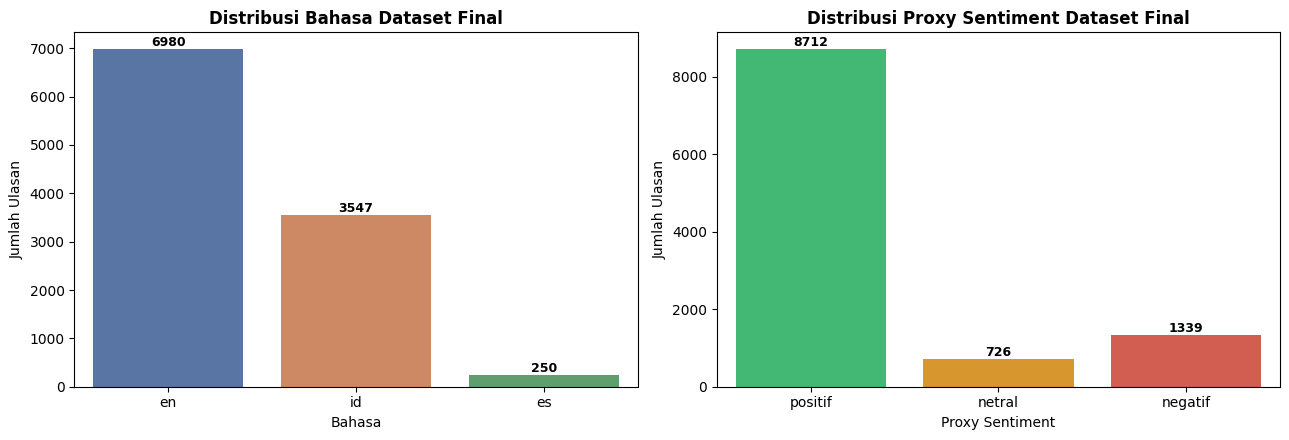

✅ Visualisasi disimpan: 02_Distribusi_Dataset_Final.png


In [ ]:
#  Visualisasi distribusi bahasa dan sentimen
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Distribusi bahasa
sns.countplot(data=df, x='language',
              order=df['language'].value_counts().index,
              ax=axes[0], palette=['#4C72B0', '#DD8452', '#55A868'])
axes[0].set_title('Distribusi Bahasa Dataset Final', fontweight='bold')
axes[0].set_xlabel('Bahasa')
axes[0].set_ylabel('Jumlah Ulasan')
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%d', fontweight='bold', fontsize=9)

# Distribusi sentimen
sns.countplot(data=df, x='proxy_sentiment',
              order=['positif', 'netral', 'negatif'],
              ax=axes[1], palette=['#2ecc71', '#f39c12', '#e74c3c'])
axes[1].set_title('Distribusi Proxy Sentiment Dataset Final', fontweight='bold')
axes[1].set_xlabel('Proxy Sentiment')
axes[1].set_ylabel('Jumlah Ulasan')
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%d', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('02_Distribusi_Dataset_Final.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualisasi disimpan: 02_Distribusi_Dataset_Final.png")

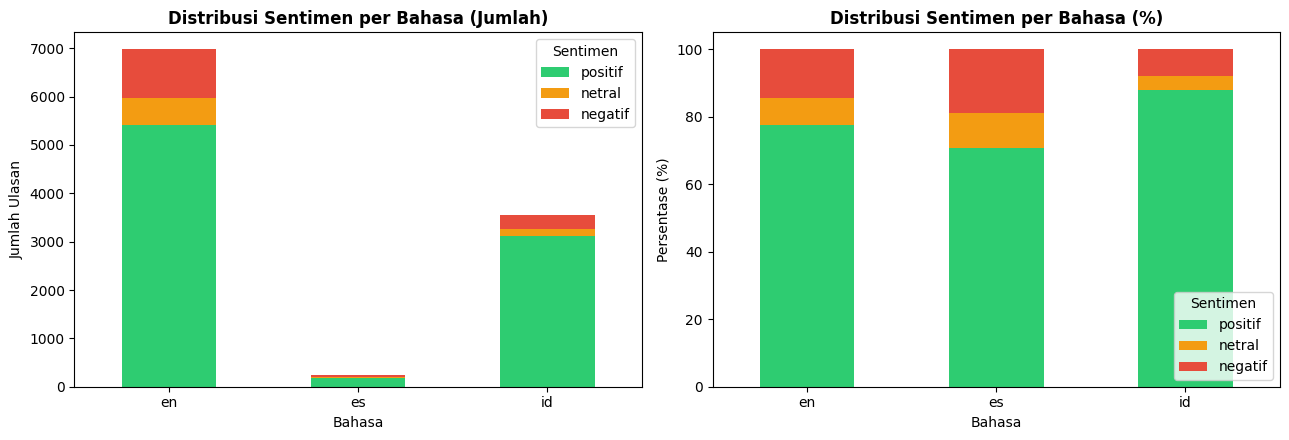

✅ Visualisasi disimpan: 03_Distribusi_Sentimen_per_Bahasa.png


In [ ]:
# Visualisasi distribusi sentimen per bahasa
cross = pd.crosstab(df['language'], df['proxy_sentiment'])
cross = cross.reindex(columns=['positif', 'netral', 'negatif'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Stacked bar - jumlah absolut
cross.plot(kind='bar', stacked=True, ax=axes[0],
           color=['#2ecc71', '#f39c12', '#e74c3c'])
axes[0].set_title('Distribusi Sentimen per Bahasa (Jumlah)', fontweight='bold')
axes[0].set_xlabel('Bahasa')
axes[0].set_ylabel('Jumlah Ulasan')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Sentimen')

# Stacked bar - persentase
cross_pct = cross.div(cross.sum(axis=1), axis=0).mul(100)
cross_pct.plot(kind='bar', stacked=True, ax=axes[1],
               color=['#2ecc71', '#f39c12', '#e74c3c'])
axes[1].set_title('Distribusi Sentimen per Bahasa (%)', fontweight='bold')
axes[1].set_xlabel('Bahasa')
axes[1].set_ylabel('Persentase (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Sentimen', loc='lower right')

plt.tight_layout()
plt.savefig('03_Distribusi_Sentimen_per_Bahasa.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualisasi disimpan: 03_Distribusi_Sentimen_per_Bahasa.png")

## Section 8 — Pembagian Dataset (*Stratified Sampling*)

Dataset dibagi menjadi tiga subset dengan rasio **70 : 15 : 15**
menggunakan metode *stratified sampling* berdasarkan **kombinasi
atribut bahasa dan label sentimen** (*multi-dimensional stratification*).

Pendekatan ini memastikan proporsi setiap kombinasi bahasa × sentimen
tetap konsisten pada seluruh subset, sehingga karakteristik data terjaga
selama proses pelatihan maupun evaluasi model.

In [ ]:
# Buat kolom stratifikasi gabungan (bahasa + sentimen)
df['stratify_col'] = df['language'] + '_' + df['proxy_sentiment']

print("📊 Distribusi kombinasi bahasa × sentimen (kolom stratifikasi):")
strat_counts = df['stratify_col'].value_counts().sort_index()
print(strat_counts)

# Cek apakah ada kombinasi dengan jumlah terlalu kecil untuk distratifikasi
too_small = strat_counts[strat_counts < 3]
if len(too_small) > 0:
    print(f"\n⚠️  Peringatan: kombinasi berikut memiliki < 3 sampel:")
    print(too_small)
else:
    print(f"\n✅ Semua kombinasi memiliki jumlah sampel memadai untuk stratifikasi.")

📊 Distribusi kombinasi bahasa × sentimen (kolom stratifikasi):
stratify_col
en_negatif    1009
en_netral      553
en_positif    5418
es_negatif      47
es_netral       26
es_positif     177
id_negatif     283
id_netral      147
id_positif    3117
Name: count, dtype: int64

✅ Semua kombinasi memiliki jumlah sampel memadai untuk stratifikasi.


In [ ]:
# Pembagian dataset 70:15:15 dengan stratified sampling
# Tahap 1: pisahkan train (70%) dari sisanya (30%)
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    stratify=df['stratify_col']
)

# Tahap 2: bagi sisanya menjadi validation (15%) dan test (15%)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df['stratify_col']
)

print("=" * 55)
print("✅ PEMBAGIAN DATASET SELESAI")
print("=" * 55)
print(f"\nTotal dataset    : {len(df):,} ulasan")
print(f"\n┌────────────────┬───────────┬────────────┐")
print(f"│ Subset         │  Jumlah   │ Persentase │")
print(f"├────────────────┼───────────┼────────────┤")
print(f"│ Train set      │  {len(train_df):>6,}   │   {len(train_df)/len(df)*100:>5.2f}%   │")
print(f"│ Validation set │  {len(val_df):>6,}   │   {len(val_df)/len(df)*100:>5.2f}%   │")
print(f"│ Test set       │  {len(test_df):>6,}   │   {len(test_df)/len(df)*100:>5.2f}%   │")
print(f"├────────────────┼───────────┼────────────┤")
print(f"│ Total          │  {len(train_df)+len(val_df)+len(test_df):>6,}   │  100.00%   │")
print(f"└────────────────┴───────────┴────────────┘")

✅ PEMBAGIAN DATASET SELESAI

Total dataset    : 10,777 ulasan

┌────────────────┬───────────┬────────────┐
│ Subset         │  Jumlah   │ Persentase │
├────────────────┼───────────┼────────────┤
│ Train set      │   7,543   │   69.99%   │
│ Validation set │   1,617   │   15.00%   │
│ Test set       │   1,617   │   15.00%   │
├────────────────┼───────────┼────────────┤
│ Total          │  10,777   │  100.00%   │
└────────────────┴───────────┴────────────┘


## Section 9 — Verifikasi Proporsi Hasil Pembagian

Pemeriksaan apakah proporsi bahasa dan sentimen pada ketiga subset
tetap konsisten dengan distribusi pada dataset keseluruhan.
Ini membuktikan bahwa *stratified sampling* berhasil menjaga
representasi proporsional setiap kelas.

In [ ]:
# Fungsi tampilkan distribusi per subset
def show_distribution(data, name):
    print(f"\n{'='*55}")
    print(f"  {name}  (n = {len(data):,})")
    print(f"{'='*55}")

    print(f"\n  Distribusi bahasa:")
    lang_dist = data['language'].value_counts()
    for lang, count in lang_dist.items():
        print(f"    {lang:<5}: {count:>6,} ({count/len(data)*100:>5.2f}%)")

    print(f"\n  Distribusi proxy sentiment:")
    sent_dist = data['proxy_sentiment'].value_counts()
    for sent, count in sent_dist.items():
        print(f"    {sent:<10}: {count:>6,} ({count/len(data)*100:>5.2f}%)")

    print(f"\n  Crosstab bahasa × sentimen:")
    ct = pd.crosstab(data['language'], data['proxy_sentiment'])
    print(ct.to_string().replace('\n', '\n    '))


show_distribution(train_df, "TRAIN SET")
show_distribution(val_df, "VALIDATION SET")
show_distribution(test_df, "TEST SET")


  TRAIN SET  (n = 7,543)

  Distribusi bahasa:
    en   :  4,885 (64.76%)
    id   :  2,483 (32.92%)
    es   :    175 ( 2.32%)

  Distribusi proxy sentiment:
    positif   :  6,098 (80.84%)
    negatif   :    937 (12.42%)
    netral    :    508 ( 6.73%)

  Crosstab bahasa × sentimen:
proxy_sentiment  negatif  netral  positif
    language                                 
    en                   706     387     3792
    es                    33      18      124
    id                   198     103     2182

  VALIDATION SET  (n = 1,617)

  Distribusi bahasa:
    en   :  1,048 (64.81%)
    id   :    531 (32.84%)
    es   :     38 ( 2.35%)

  Distribusi proxy sentiment:
    positif   :  1,307 (80.83%)
    negatif   :    201 (12.43%)
    netral    :    109 ( 6.74%)

  Crosstab bahasa × sentimen:
proxy_sentiment  negatif  netral  positif
    language                                 
    en                   152      83      813
    es                     7       4       27
    id         

In [ ]:
# Tabel perbandingan proporsi antar subset
print("=" * 70)
print("VERIFIKASI KONSISTENSI PROPORSI ANTAR SUBSET")
print("=" * 70)

# Perbandingan proporsi sentimen
comparison_sent = pd.DataFrame({
    'Dataset Penuh' : df['proxy_sentiment'].value_counts(normalize=True).mul(100).round(2),
    'Train'         : train_df['proxy_sentiment'].value_counts(normalize=True).mul(100).round(2),
    'Validation'    : val_df['proxy_sentiment'].value_counts(normalize=True).mul(100).round(2),
    'Test'          : test_df['proxy_sentiment'].value_counts(normalize=True).mul(100).round(2),
})
print("\n📊 Proporsi Sentimen (%):")
print(comparison_sent)

# Perbandingan proporsi bahasa
comparison_lang = pd.DataFrame({
    'Dataset Penuh' : df['language'].value_counts(normalize=True).mul(100).round(2),
    'Train'         : train_df['language'].value_counts(normalize=True).mul(100).round(2),
    'Validation'    : val_df['language'].value_counts(normalize=True).mul(100).round(2),
    'Test'          : test_df['language'].value_counts(normalize=True).mul(100).round(2),
})
print("\n📊 Proporsi Bahasa (%):")
print(comparison_lang)

print("\n✅ Proporsi yang konsisten antar subset membuktikan bahwa")
print("   stratified sampling berhasil menjaga representasi setiap kelas.")

VERIFIKASI KONSISTENSI PROPORSI ANTAR SUBSET

📊 Proporsi Sentimen (%):
                 Dataset Penuh  Train  Validation   Test
proxy_sentiment                                         
positif                  80.84  80.84       80.83  80.83
negatif                  12.42  12.42       12.43  12.43
netral                    6.74   6.73        6.74   6.74

📊 Proporsi Bahasa (%):
          Dataset Penuh  Train  Validation   Test
language                                         
en                64.77  64.76       64.81  64.75
id                32.91  32.92       32.84  32.96
es                 2.32   2.32        2.35   2.29

✅ Proporsi yang konsisten antar subset membuktikan bahwa
   stratified sampling berhasil menjaga representasi setiap kelas.


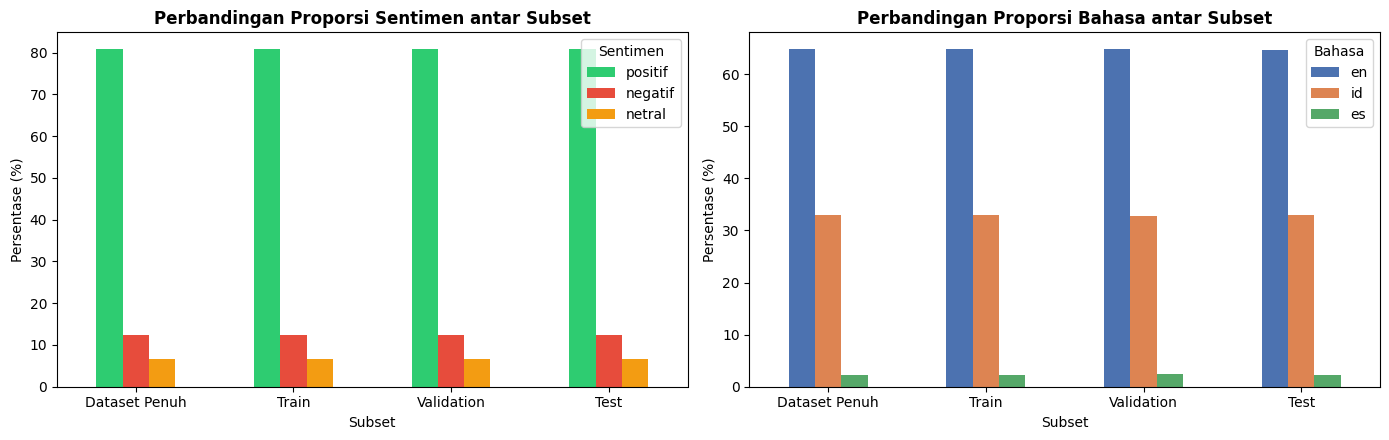

✅ Visualisasi disimpan: 04_Verifikasi_Proporsi_Antar_Subset.png


In [ ]:
# Visualisasi perbandingan proporsi antar subset
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

comparison_sent.T.plot(kind='bar', ax=axes[0], stacked=False,
                       color=['#2ecc71', '#e74c3c', '#f39c12'])
axes[0].set_title('Perbandingan Proporsi Sentimen antar Subset', fontweight='bold')
axes[0].set_xlabel('Subset')
axes[0].set_ylabel('Persentase (%)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Sentimen')

comparison_lang.T.plot(kind='bar', ax=axes[1], stacked=False,
                       color=['#4C72B0', '#DD8452', '#55A868'])
axes[1].set_title('Perbandingan Proporsi Bahasa antar Subset', fontweight='bold')
axes[1].set_xlabel('Subset')
axes[1].set_ylabel('Persentase (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Bahasa')

plt.tight_layout()
plt.savefig('04_Verifikasi_Proporsi_Antar_Subset.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualisasi disimpan: 04_Verifikasi_Proporsi_Antar_Subset.png")

## Section 10 — Ekspor Dataset Final dan Subset

Dataset final beserta ketiga subset diekspor sebagai file Excel
untuk digunakan pada Notebook 03 (Implementasi dan Evaluasi Model).

Kolom bantu `stratify_col` dihapus dari seluruh output karena
hanya digunakan pada proses pembagian dataset.

In [ ]:
# Hapus kolom bantu dan ekspor seluruh output
df_final    = df.drop(columns=['stratify_col'], errors='ignore')
train_final = train_df.drop(columns=['stratify_col'], errors='ignore').reset_index(drop=True)
val_final   = val_df.drop(columns=['stratify_col'], errors='ignore').reset_index(drop=True)
test_final  = test_df.drop(columns=['stratify_col'], errors='ignore').reset_index(drop=True)

# Ekspor ke Excel
df_final.to_excel('Dataset_Final_Preprocessed.xlsx', index=False)
train_final.to_excel('Train_Set.xlsx', index=False)
val_final.to_excel('Validation_Set.xlsx', index=False)
test_final.to_excel('Test_Set.xlsx', index=False)

print("=" * 55)
print("🎉 NOTEBOOK 02 SELESAI!")
print("=" * 55)
print(f"\n📁 File berhasil disimpan:")
print(f"   1. Dataset_Final_Preprocessed.xlsx  ({len(df_final):,} baris, {len(df_final.columns)} kolom)")
print(f"   2. Train_Set.xlsx                   ({len(train_final):,} baris)")
print(f"   3. Validation_Set.xlsx              ({len(val_final):,} baris)")
print(f"   4. Test_Set.xlsx                    ({len(test_final):,} baris)")

print(f"\n📊 RINGKASAN AKHIR:")
print(f"┌────────────────────────────────────────────────────┐")
print(f"│  Dataset final       : {len(df_final):>7,} ulasan            │")
print(f"│  Jumlah kolom        : {len(df_final.columns):>7}                   │")
print(f"│  Train / Val / Test  : {len(train_final):,} / {len(val_final):,} / {len(test_final):,}         │")
print(f"└────────────────────────────────────────────────────┘")

print(f"\n➡️  Lanjutkan ke Notebook 03 untuk implementasi")
print(f"   dan evaluasi lima pendekatan model NLP.")

🎉 NOTEBOOK 02 SELESAI!

📁 File berhasil disimpan:
   1. Dataset_Final_Preprocessed.xlsx  (10,777 baris, 13 kolom)
   2. Train_Set.xlsx                   (7,543 baris)
   3. Validation_Set.xlsx              (1,617 baris)
   4. Test_Set.xlsx                    (1,617 baris)

📊 RINGKASAN AKHIR:
┌────────────────────────────────────────────────────┐
│  Dataset final       :  10,777 ulasan            │
│  Jumlah kolom        :      13                   │
│  Train / Val / Test  : 7,543 / 1,617 / 1,617         │
└────────────────────────────────────────────────────┘

➡️  Lanjutkan ke Notebook 03 untuk implementasi
   dan evaluasi lima pendekatan model NLP.
